### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [27]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [28]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from pprint import pprint

messages = [AIMessage(content=f"please help me how can i help you?", name="openaillm")]
messages.append(HumanMessage(content=f"i want to learn coding", name="saran"))
messages.append(AIMessage(content=f"which programming language do you want to learn?", name="openaillm"))
messages.append(HumanMessage(content=f"i want to learn python", name="saran"))

messages

[AIMessage(content='please help me how can i help you?', additional_kwargs={}, response_metadata={}, name='openaillm', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='i want to learn coding', additional_kwargs={}, response_metadata={}, name='saran'),
 AIMessage(content='which programming language do you want to learn?', additional_kwargs={}, response_metadata={}, name='openaillm', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='i want to learn python', additional_kwargs={}, response_metadata={}, name='saran')]

In [29]:
for i in messages:
    i.pretty_print()

================================== Ai Message ==================================
Name: openaillm

please help me how can i help you?
================================ Human Message =================================
Name: saran

i want to learn coding
================================== Ai Message ==================================
Name: openaillm

which programming language do you want to learn?
================================ Human Message =================================
Name: saran

i want to learn python


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [30]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3.6-27b")
result=llm.invoke(messages)
result

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User wants to learn Python programming.\n   - This is a common, well-structured request. I need to provide a clear, actionable, and beginner-friendly roadmap.\n\n2.  **Identify Key Components of Learning Python:**\n   - Prerequisites/Setup\n   - Basic Concepts\n   - Intermediate Concepts\n   - Projects/Practice\n   - Resources (free & paid)\n   - Learning path/structure\n   - Tips for success\n\n3.  **Structure the Response:**\n   - Acknowledge & encourage\n   - Provide a step-by-step learning roadmap\n   - Recommend resources (free/paid)\n   - Suggest practice methods\n   - Offer next steps/how I can help further\n   - Keep it concise but comprehensive\n\n4.  **Draft - Section by Section:**\n   *(Introduction)* Great choice! Python is one of the most beginner-friendly and versatile programming languages. It’s widely used in web development, data science, automation, AI, and more.\n\n   *(Ste

In [31]:
result.response_metadata

{'token_usage': {'completion_tokens': 1470,
  'prompt_tokens': 58,
  'total_tokens': 1528,
  'completion_time': 2.920540897,
  'completion_tokens_details': None,
  'prompt_time': 0.00438293,
  'prompt_tokens_details': None,
  'queue_time': 0.048110659,
  'total_time': 2.9249238269999998},
 'model_name': 'qwen/qwen3.6-27b',
 'system_fingerprint': 'fp_60e0d2f248',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [32]:
def add(a:int, b:int)->int:
    """ add a and b 
    args:
        a(int): first int
        b(int): second int
    
    returns:
        int
    """
    return a+b

In [33]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x000002286BD90920>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002286BD970E0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [34]:
llm_with_tools=llm.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Krish")])
tool_call

AIMessage(content='', additional_kwargs={'reasoning_content': "The user is asking for the result of a simple addition: 2 plus 2.\nI have a tool named `add` that takes two integers `a` and `b` and returns their sum.\nI should use this tool to calculate the answer.\n\n1.  **Identify the tool:** `add`\n2.  **Identify the arguments:** `a = 2`, `b = 2`\n3.  **Construct the tool call:** `add(a=2, b=2)`\n4.  **Execute the tool call.**\n5.  **Formulate the response based on the result.**\n\nLet's call the tool.\n", 'tool_calls': [{'id': 'pm1xcs92k', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 178, 'prompt_tokens': 307, 'total_tokens': 485, 'completion_time': 0.337660104, 'completion_tokens_details': {'reasoning_tokens': 141}, 'prompt_time': 0.021562997, 'prompt_tokens_details': None, 'queue_time': 0.047247542, 'total_time': 0.359223101}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_49d6

In [35]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'pm1xcs92k',
  'type': 'tool_call'}]

### Using messages as state

In [36]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages:list[AnyMessage]

#### Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [37]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

### Reducers with add_messages

In [39]:
initial_messages=[AIMessage(content=f"please tell me how can i help?", name="openaillm")]
initial_messages.append(HumanMessage(content=f"i want to learn coding", name="saran"))
initial_messages

[AIMessage(content='please tell me how can i help?', additional_kwargs={}, response_metadata={}, name='openaillm', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='i want to learn coding', additional_kwargs={}, response_metadata={}, name='saran')]

In [40]:
aimessage = AIMessage(content=f"which programming you want to learn", name="openaillm")
aimessage

AIMessage(content='which programming you want to learn', additional_kwargs={}, response_metadata={}, name='openaillm', tool_calls=[], invalid_tool_calls=[])

In [41]:
add_messages(initial_messages, aimessage)

[AIMessage(content='please tell me how can i help?', additional_kwargs={}, response_metadata={}, name='openaillm', id='162812ac-6f87-4366-810c-d081ac92511d', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='i want to learn coding', additional_kwargs={}, response_metadata={}, name='saran', id='a75c6c81-b7e4-4cb0-b6ee-78f417c1aa31'),
 AIMessage(content='which programming you want to learn', additional_kwargs={}, response_metadata={}, name='openaillm', id='9ed17acd-d664-4e6c-9caa-7e30b2c5f22b', tool_calls=[], invalid_tool_calls=[])]

In [42]:
def llm_tool(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

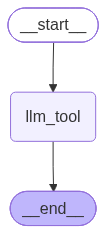

In [43]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (2d15yvcss)
 Call ID: 2d15yvcss
  Args:
    a: 2
    b: 2


In [45]:
tools = [add]

In [46]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool")
builder.add_conditional_edges("llm_tool", tools_condition)
builder.add_edge("tools",END)
graph_builder = builder.compile()

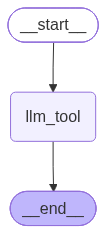

In [47]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (jpa50z2at)
 Call ID: jpa50z2at
  Args:
    a: 2
    b: 2


In [49]:
messages=graph.invoke({"messages":"What Machine Learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What Machine Learning
================================== Ai Message ==================================

**Machine Learning (ML)** is a branch of artificial intelligence that focuses on building systems that can learn from data and improve over time without being explicitly programmed for every task. Instead of following rigid, hand-coded rules, ML algorithms identify patterns in data and use those patterns to make predictions, classifications, or decisions.

### 🔑 Core Idea
Traditional programming: `Rules + Data → Answers`  
Machine Learning: `Data + Answers → Rules (that can be applied to new data)`

### 📊 Main Types
1. **Supervised Learning**  
   - Learns from labeled data (input-output pairs).  
   - *Examples:* Email spam detection, image classification, price prediction.
2. **Unsupervised Learning**  
   - Finds hidden structures in unlabeled data.  
   - *Examples:* Customer segmentation, anomaly d